# Step 8: Medical Desert Analysis & Visualization Dashboard

This notebook:
1. Performs comprehensive medical desert analysis with scoring
2. Creates interactive maps with Folium
3. Builds charts and visualizations using matplotlib
4. Generates a Databricks-native dashboard with displayHTML
5. Includes the interactive query interface

**Run notebooks 00–07 first!**

## 8A. Install Packages

In [0]:
%pip install folium matplotlib seaborn langchain langchain-groq mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 22.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.1/94.1 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.2/168.2 kB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 27.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 43.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 25.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 26.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [0]:
dbutils.library.restartPython()

## 8B. Configuration & Load Data

In [0]:
import os
import json
import folium
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import base64
from io import BytesIO
import mlflow
from pyspark.sql import functions as F
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

# ============================================================
# CONFIG
# ============================================================
CATALOG = "hackathon_vf"
SCHEMA = "healthcare"
TABLE_PREFIX = f"{CATALOG}.{SCHEMA}"

try:
    spark.sql(f"USE CATALOG {CATALOG}")
    spark.sql(f"USE SCHEMA {SCHEMA}")
except Exception:
    CATALOG = "hive_metastore"
    SCHEMA = "hackathon"
    TABLE_PREFIX = f"{CATALOG}.{SCHEMA}"
    spark.sql(f"USE {SCHEMA}")

ENRICHED_TABLE = f"{TABLE_PREFIX}.facilities_enriched"
DESERT_TABLE = f"{TABLE_PREFIX}.regional_analysis"

# Load data
df_enriched = spark.table(ENRICHED_TABLE)
df_desert = spark.table(DESERT_TABLE)

facilities_pdf = df_enriched.toPandas()
desert_pdf = df_desert.toPandas()

print(f"Loaded {len(facilities_pdf)} facilities")
print(f"Loaded {len(desert_pdf)} regions for desert analysis")

Loaded 797 facilities
Loaded 53 regions for desert analysis


## 8C. Ghana Region Coordinates

Since the dataset doesn't have lat/lon, we use approximate centroids for each Ghana region.

In [0]:
# Approximate centroids for Ghana's regions (for map visualization)
GHANA_REGION_COORDS = {
    "Greater Accra": {"lat": 5.6037, "lon": -0.1870},
    "Ashanti": {"lat": 6.7470, "lon": -1.5209},
    "Western": {"lat": 5.3960, "lon": -2.1500},
    "Central": {"lat": 5.4510, "lon": -1.2000},
    "Eastern": {"lat": 6.2500, "lon": -0.4500},
    "Volta": {"lat": 6.6000, "lon": 0.4700},
    "Northern": {"lat": 9.4000, "lon": -1.0000},
    "Upper East": {"lat": 10.7500, "lon": -0.8500},
    "Upper West": {"lat": 10.2500, "lon": -2.1400},
    "Brong-Ahafo": {"lat": 7.9500, "lon": -1.6700},
    "Bono": {"lat": 7.9500, "lon": -2.3100},
    "Bono East": {"lat": 7.7500, "lon": -1.0500},
    "Ahafo": {"lat": 7.0000, "lon": -2.3500},
    "Western North": {"lat": 6.3000, "lon": -2.8000},
    "Oti": {"lat": 7.9000, "lon": 0.3000},
    "North East": {"lat": 10.5000, "lon": -0.2000},
    "Savannah": {"lat": 9.0000, "lon": -1.8000},
}

# Try to match facility regions to coordinates
def get_region_coords(region_name):
    """Get coordinates for a region name (fuzzy match)."""
    if not region_name:
        return None
    for key, coords in GHANA_REGION_COORDS.items():
        if key.lower() in str(region_name).lower() or str(region_name).lower() in key.lower():
            return coords
    return None

## 8D. Interactive Map - Facility Distribution

In [0]:
def create_facility_map():
    """Create an interactive Folium map showing facility distribution."""
    # Center on Ghana
    m = folium.Map(location=[7.9465, -1.0232], zoom_start=7, tiles="cartodbpositron")

    # Color scheme by facility type
    type_colors = {
        "hospital": "#e74c3c",    # Red
        "clinic": "#3498db",      # Blue
        "dentist": "#2ecc71",     # Green
        "pharmacy": "#f39c12",    # Orange
    }

    # Add markers for each facility
    # Since we don't have exact coordinates, place them at region centroids with small offsets
    import random
    random.seed(42)

    facility_counts_by_region = {}

    for _, row in facilities_pdf.iterrows():
        region = row.get("address_stateOrRegion")
        coords = get_region_coords(region)
        if not coords:
            continue

        # Add small random offset to avoid stacking
        if region not in facility_counts_by_region:
            facility_counts_by_region[region] = 0
        facility_counts_by_region[region] += 1
        offset_lat = random.uniform(-0.15, 0.15)
        offset_lon = random.uniform(-0.15, 0.15)

        ftype = row.get("facilityTypeId", "unknown")
        color = type_colors.get(ftype, "#95a5a6")
        name = row.get("name", "Unknown")
        city = row.get("address_city", "")
        docs = row.get("numberDoctors", "N/A")
        beds = row.get("capacity", "N/A")
        specs = row.get("num_specialties", 0)

        # Check for anomaly flags
        flag_cols = [c for c in facilities_pdf.columns if c.startswith("flag_")]
        has_flag = any(row.get(fc) == True for fc in flag_cols)
        icon_color = "red" if has_flag else "blue"

        popup_html = f"""
        <div style="min-width: 200px;">
            <h4 style="margin: 0; color: {color};">{name}</h4>
            <p style="margin: 2px 0;"><b>Type:</b> {ftype}</p>
            <p style="margin: 2px 0;"><b>Location:</b> {city}, {region}</p>
            <p style="margin: 2px 0;"><b>Doctors:</b> {docs}</p>
            <p style="margin: 2px 0;"><b>Beds:</b> {beds}</p>
            <p style="margin: 2px 0;"><b>Specialties:</b> {specs}</p>
            {'<p style="margin: 2px 0; color: red;"><b>⚠ Anomaly flagged</b></p>' if has_flag else ''}
        </div>
        """

        folium.CircleMarker(
            location=[coords["lat"] + offset_lat, coords["lon"] + offset_lon],
            radius=5 if ftype != "hospital" else 8,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7 if not has_flag else 0.9,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"{name} ({ftype})"
        ).add_to(m)

    # Add legend
    legend_html = """
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
                background-color: white; padding: 10px; border-radius: 5px;
                border: 2px solid grey; font-size: 12px;">
        <h4 style="margin: 0 0 5px 0;">Facility Types</h4>
        <p style="margin: 2px;"><span style="color: #e74c3c;">●</span> Hospital</p>
        <p style="margin: 2px;"><span style="color: #3498db;">●</span> Clinic</p>
        <p style="margin: 2px;"><span style="color: #2ecc71;">●</span> Dentist</p>
        <p style="margin: 2px;"><span style="color: #f39c12;">●</span> Pharmacy</p>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    return m

In [0]:
# Render the facility map
facility_map = create_facility_map()
displayHTML(facility_map._repr_html_())

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap-glyphicons.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_72514f42e57697fffdcad1d5f1a0746f {
 position: relative;
 width: 100.0%;
 height: 100.0%;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>

 <style>html, body {
 width: 100%;
 height: 100%;
 margin: 0;
 padding: 0;
 }
 </style>

 <style>#map {
 position:absolute;
 top:0;
 bottom:0;
 right:0;
 left:0;
 }
 </style>

 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>

 
</head>
<body>
 
 
 <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
 background-color: white; padding: 10px; border-radius: 5px;
 border: 2px solid grey; font-size: 12px;">
 <h4 style="margin: 0 0 5px 0;">Facility Types</h4>
 <p style="margin: 2px;"><span style="color: #e74c3c;">●</span> Hospital</p>
 <p style="margin: 2px;"><span style="color: #3498db;">●</span> Clinic</p>
 <p style="margin: 2px;"><span style="color: #2ecc71;">●</span> Dentist</p>
 <p style="margin: 2px;"><span style="color: #f39c12;">●</span> Pharmacy</p>
 </div>
 
 
 <div class="folium-map" id="map_72514f42e57697fffdcad1d5f1a0746f" ></div>
 
</body>
<script>
 
 
 var map_72514f42e57697fffdcad1d5f1a0746f = L.map(
 "map_72514f42e57697fffdcad1d5f1a0746f",
 {
 center: [7.9465, -1.0232],
 crs: L.CRS.EPSG3857,
 ...{
 "zoom": 7,
 "zoomControl": true,
 "preferCanvas": false,
}

 }
 );

 

 
 
 var tile_layer_a38840b6711cf014f698b55acbf0ae88 = L.tileLayer(
 "https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
 {
 "minZoom": 0,
 "maxZoom": 20,
 "maxNativeZoom": 20,
 "noWrap": false,
 "attribution": "\u0026copy; \u003ca href=\"https://www.openstreetmap.org/copyright\"\u003eOpenStreetMap\u003c/a\u003e contributors \u0026copy; \u003ca href=\"https://carto.com/attributions\"\u003eCARTO\u003c/a\u003e",
 "subdomains": "abcd",
 "detectRetina": false,
 "tms": false,
 "opacity": 1,
}

 );
 
 
 tile_layer_a38840b6711cf014f698b55acbf0ae88.addTo(map_72514f42e57697fffdcad1d5f1a0746f);
 
 
 var circle_marker_ed6514efc96b46a40b6a482f863f461b = L.circleMarker(
 [5.437828039537365, -2.2924967734332],
 {"bubblingMouseEvents": true, "color": "#e74c3c", "dashArray": null, "dashOffset": null, "fill": true, "fillColor": "#e74c3c", "fillOpacity": 0.7, "fillRule": "evenodd", "lineCap": "round", "lineJoin": "round", "opacity": 1.0, "radius": 8, "stroke": true, "weight": 3}
 ).addTo(map_72514f42e57697fffdcad1d5f1a0746f);
 
 
 var popup_d30b85b663189171ea0c87671958fdae = L.popup({
 "maxWidth": 300,
});

 
 
 var html_97c5c0d5ba9dfc5cba619828830c2791 = $(`<div id="html_97c5c0d5ba9dfc5cba619828830c2791" style="width: 100.0%; height: 100.0%;"> <div style="min-width: 200px;"> <h4 style="margin: 0; color: #e74

## 8E. Medical Desert Heatmap

In [0]:
def create_desert_map():
    """Create a map highlighting medical desert regions."""
    m = folium.Map(location=[7.9465, -1.0232], zoom_start=7, tiles="cartodbdark_matter")

    for _, row in desert_pdf.iterrows():
        region = row.get("address_stateOrRegion")
        coords = get_region_coords(region)
        if not coords:
            continue

        score = row.get("desert_score", 0)
        fac_count = row.get("facility_count", 0)
        docs = row.get("total_doctors", 0)
        beds = row.get("total_beds", 0)
        has_surgery = row.get("has_surgery", 0)
        has_emergency = row.get("has_emergency", 0)

        # Color based on desert score (higher = more underserved = redder)
        if score > 80:
            color = "#e74c3c"  # Dark red
            opacity = 0.8
        elif score > 50:
            color = "#e67e22"  # Orange
            opacity = 0.6
        elif score > 20:
            color = "#f1c40f"  # Yellow
            opacity = 0.5
        else:
            color = "#2ecc71"  # Green
            opacity = 0.4

        # Circle size based on inverse of facility count
        radius = max(15, 50 - fac_count * 2)

        popup_html = f"""
        <div style="min-width: 220px; color: white; background: rgba(0,0,0,0.8); padding: 8px; border-radius: 5px;">
            <h3 style="margin: 0; color: {color};">{region}</h3>
            <hr style="margin: 5px 0; border-color: {color};">
            <p style="margin: 2px 0;">🏥 Facilities: <b>{fac_count}</b></p>
            <p style="margin: 2px 0;">👨‍⚕️ Doctors: <b>{docs}</b></p>
            <p style="margin: 2px 0;">🛏️ Beds: <b>{beds}</b></p>
            <p style="margin: 2px 0;">🔪 Surgery: <b>{'Yes' if has_surgery > 0 else '❌ NO'}</b></p>
            <p style="margin: 2px 0;">🚑 Emergency: <b>{'Yes' if has_emergency > 0 else '❌ NO'}</b></p>
            <p style="margin: 2px 0;">📊 Desert Score: <b>{score}</b></p>
        </div>
        """

        folium.CircleMarker(
            location=[coords["lat"], coords["lon"]],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"{region} (Desert Score: {score})"
        ).add_to(m)

    # Add title
    title_html = """
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
                z-index: 1000; background-color: rgba(0,0,0,0.8); padding: 10px 20px;
                border-radius: 5px; color: white; font-size: 16px; font-weight: bold;">
        🏜️ Ghana Medical Desert Map — Virtue Foundation
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))

    # Legend
    legend_html = """
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
                background-color: rgba(0,0,0,0.8); padding: 10px; border-radius: 5px;
                border: 1px solid grey; font-size: 12px; color: white;">
        <h4 style="margin: 0 0 5px 0;">Desert Score</h4>
        <p style="margin: 2px;"><span style="color: #e74c3c;">●</span> Critical (&gt;80)</p>
        <p style="margin: 2px;"><span style="color: #e67e22;">●</span> High (50-80)</p>
        <p style="margin: 2px;"><span style="color: #f1c40f;">●</span> Moderate (20-50)</p>
        <p style="margin: 2px;"><span style="color: #2ecc71;">●</span> Adequate (&lt;20)</p>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    return m

In [0]:
desert_map = create_desert_map()
displayHTML(desert_map._repr_html_())

## 8F. Analysis Charts

In [0]:
def plot_to_html(fig):
    """Convert a matplotlib figure to HTML img tag for displayHTML."""
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    buf.seek(0)
    img_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    plt.close(fig)
    return f'<img src="data:image/png;base64,{img_b64}" style="max-width: 100%;">'


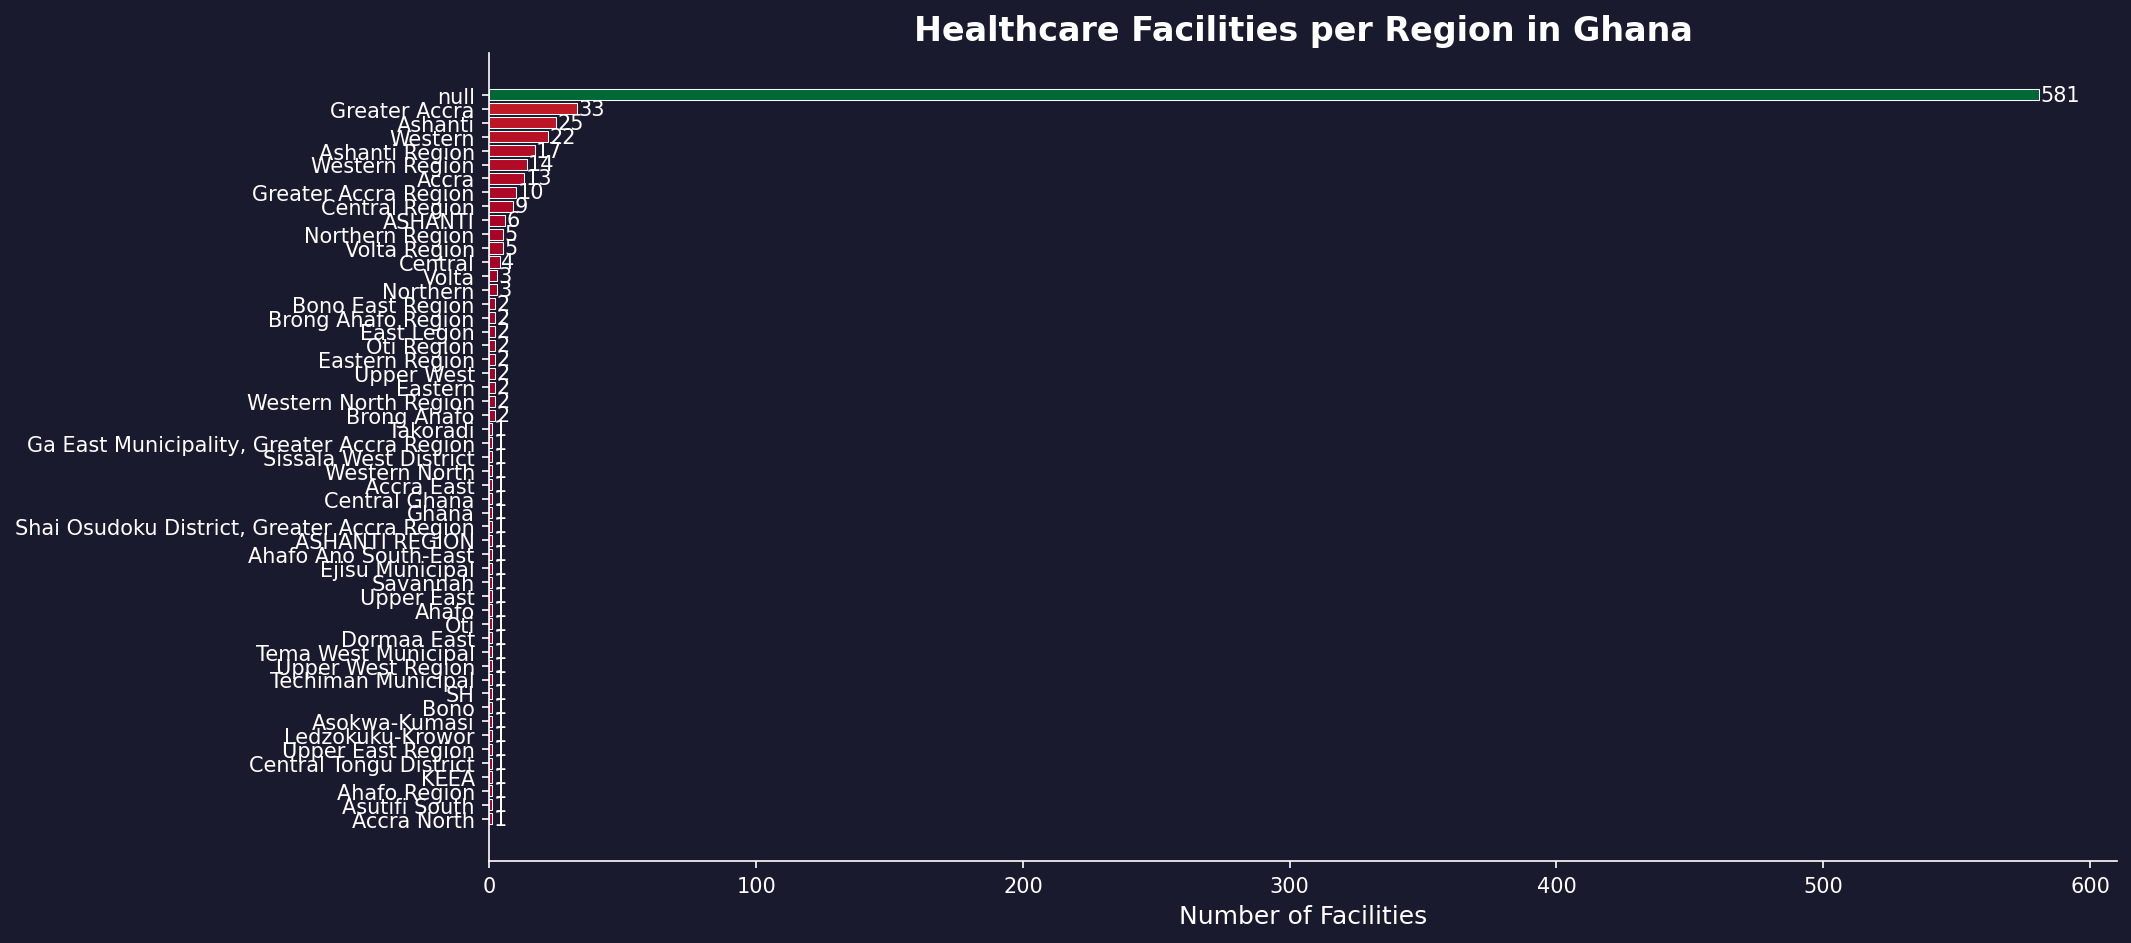

In [0]:
# Chart 1: Facilities per Region
fig, ax = plt.subplots(figsize=(14, 7))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

region_counts = facilities_pdf["address_stateOrRegion"].value_counts().sort_values()
colors = plt.cm.RdYlGn(region_counts.values / region_counts.values.max())

bars = ax.barh(region_counts.index, region_counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel("Number of Facilities", color='white', fontsize=12)
ax.set_title("Healthcare Facilities per Region in Ghana", color='white', fontsize=16, fontweight='bold')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, region_counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val),
            va='center', ha='left', color='white', fontsize=10)

chart1_html = plot_to_html(fig)
displayHTML(chart1_html)


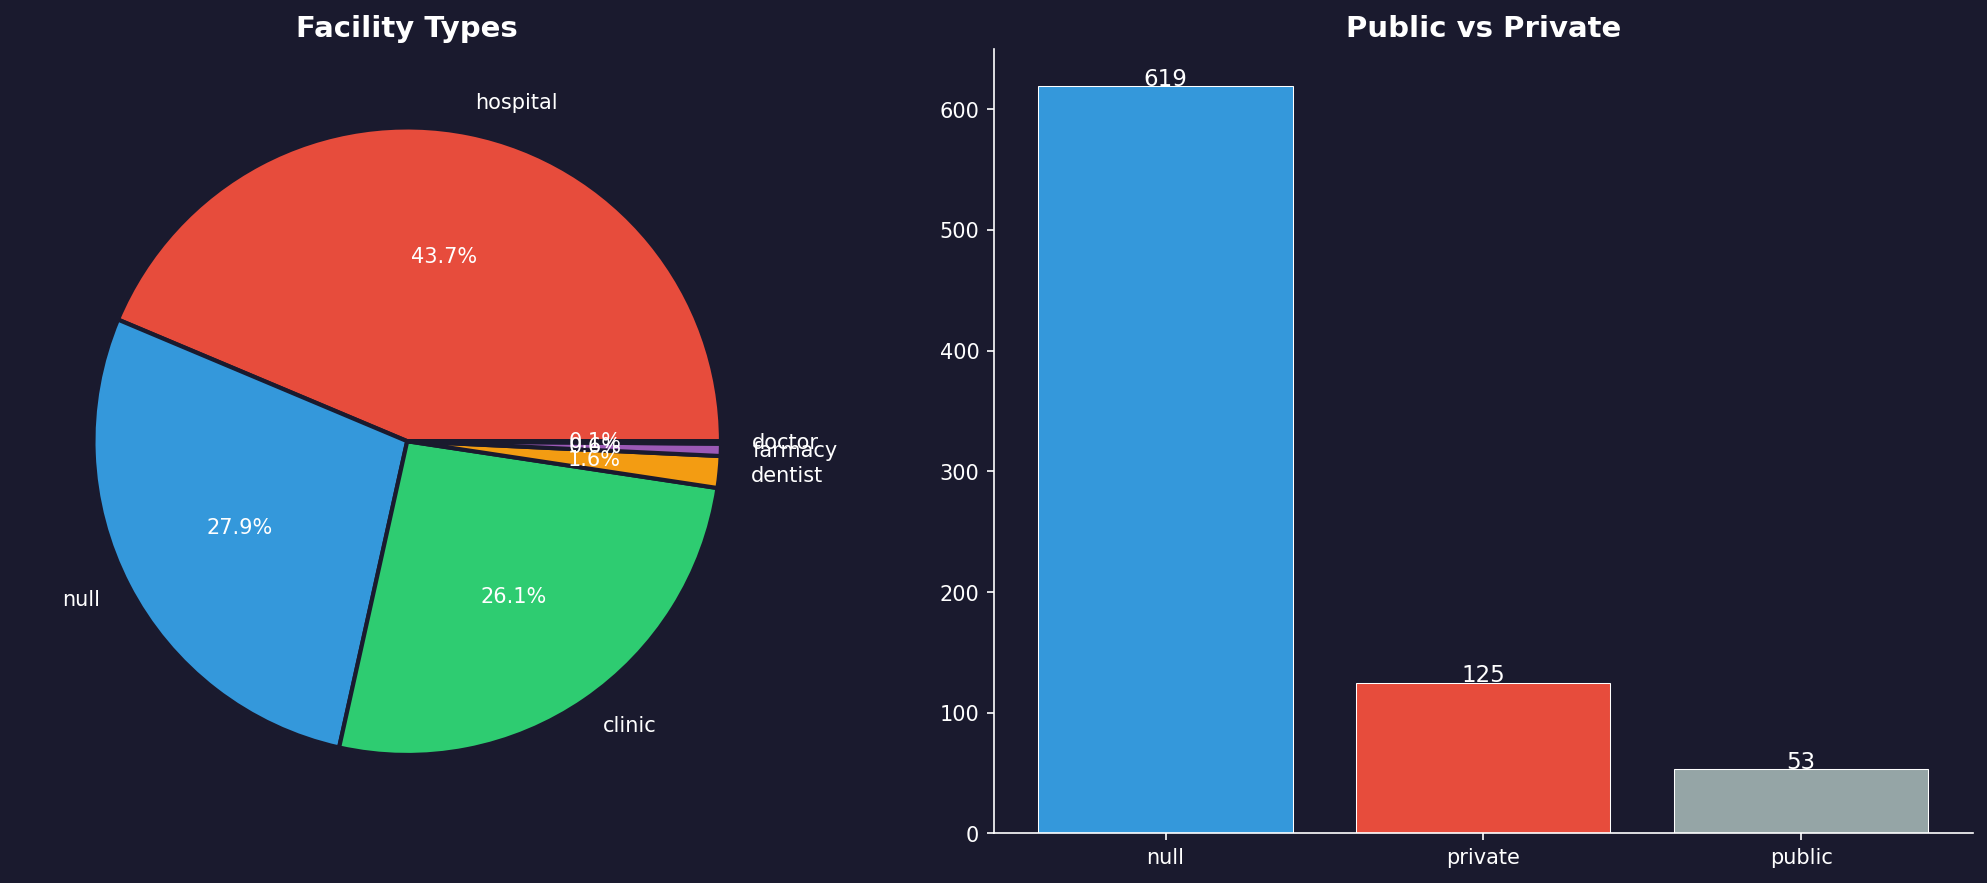

In [0]:
# Chart 2: Facility Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.set_facecolor('#1a1a2e')

# Pie chart
type_counts = facilities_pdf["facilityTypeId"].value_counts()
colors_pie = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
axes[0].set_facecolor('#1a1a2e')
wedges, texts, autotexts = axes[0].pie(
    type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
    colors=colors_pie[:len(type_counts)], textprops={'color': 'white'},
    wedgeprops={'edgecolor': '#1a1a2e', 'linewidth': 2}
)
axes[0].set_title("Facility Types", color='white', fontsize=14, fontweight='bold')

# Public vs Private
op_counts = facilities_pdf["operatorTypeId"].fillna("Unknown").value_counts()
axes[1].set_facecolor('#1a1a2e')
bars = axes[1].bar(op_counts.index, op_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'][:len(op_counts)],
                   edgecolor='white', linewidth=0.5)
axes[1].set_title("Public vs Private", color='white', fontsize=14, fontweight='bold')
axes[1].tick_params(colors='white')
axes[1].spines['bottom'].set_color('white')
axes[1].spines['left'].set_color('white')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for bar, val in zip(bars, op_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
                 ha='center', color='white', fontsize=11)

plt.tight_layout()
chart2_html = plot_to_html(fig)
displayHTML(chart2_html)


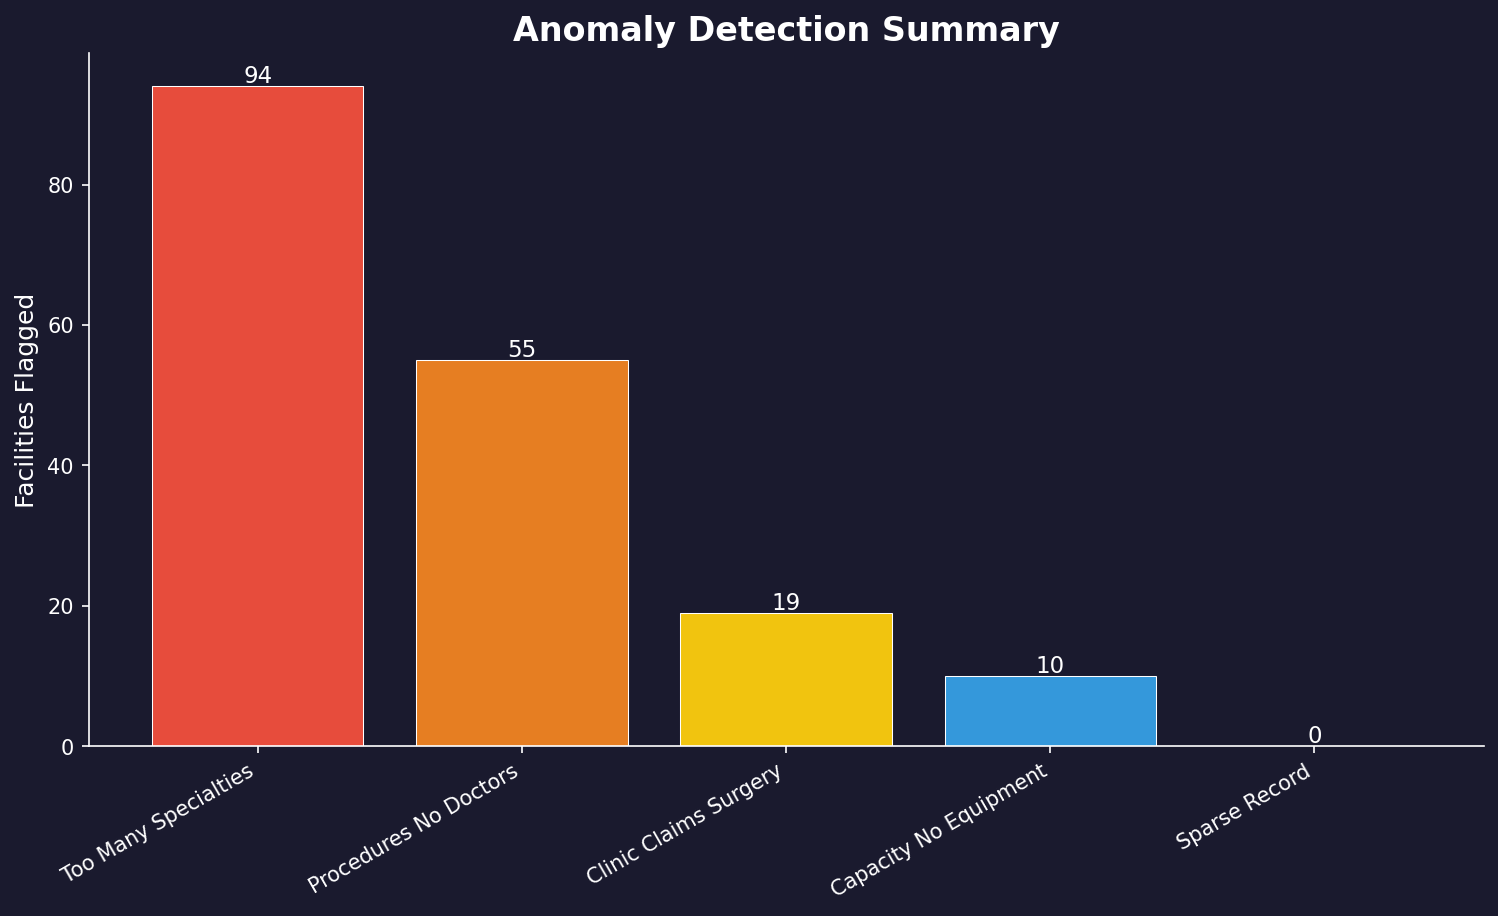

In [0]:
# Chart 3: Anomaly Flag Distribution
fig, ax = plt.subplots(figsize=(12, 6))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

flag_cols = [c for c in facilities_pdf.columns if c.startswith("flag_")]
flag_counts = {col.replace("flag_", "").replace("_", " ").title(): facilities_pdf[col].sum()
               for col in flag_cols}

sorted_flags = dict(sorted(flag_counts.items(), key=lambda x: x[1], reverse=True))
colors_flags = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#9b59b6']

bars = ax.bar(sorted_flags.keys(), sorted_flags.values(),
              color=colors_flags[:len(sorted_flags)], edgecolor='white', linewidth=0.5)
ax.set_ylabel("Facilities Flagged", color='white', fontsize=12)
ax.set_title("Anomaly Detection Summary", color='white', fontsize=16, fontweight='bold')
ax.tick_params(colors='white', axis='both')
plt.xticks(rotation=30, ha='right')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, sorted_flags.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(int(val)),
            ha='center', color='white', fontsize=11)

chart3_html = plot_to_html(fig)
displayHTML(chart3_html)


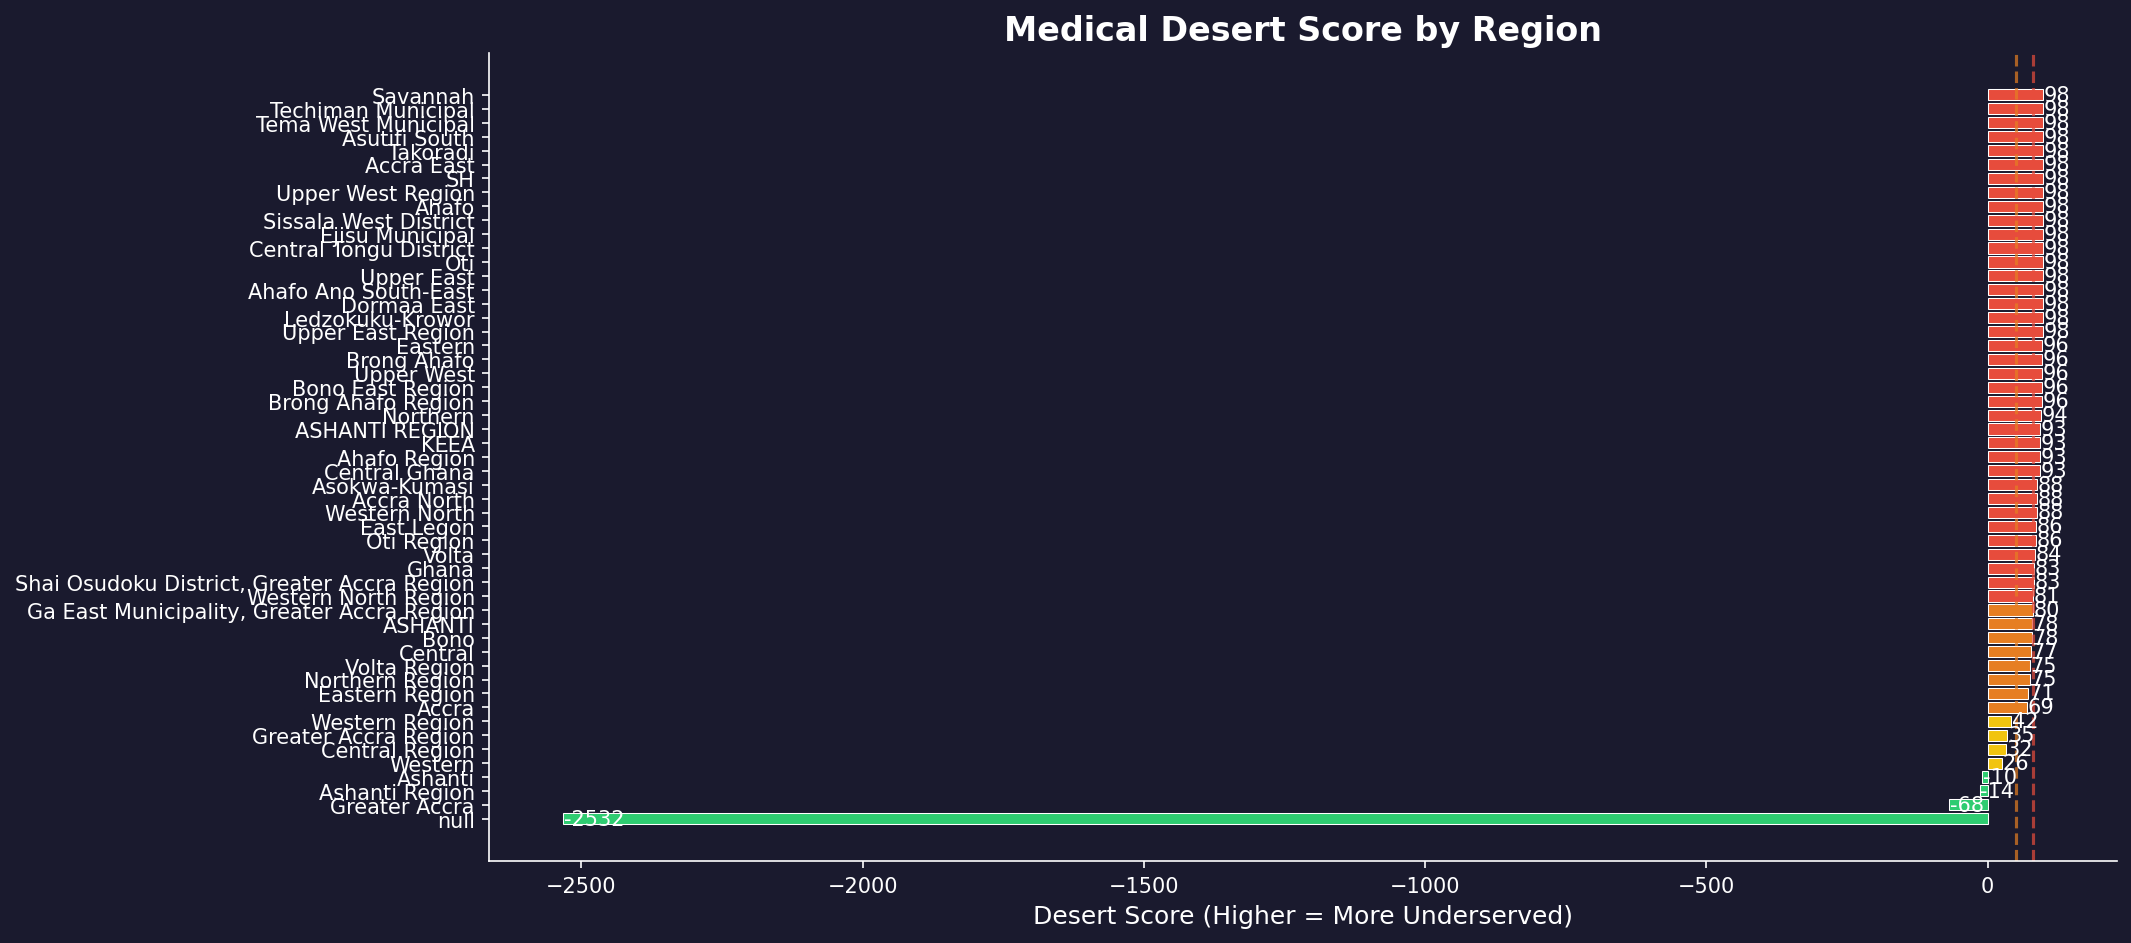

In [0]:
# Chart 4: Medical Desert Scores by Region
fig, ax = plt.subplots(figsize=(14, 7))
fig.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

desert_sorted = desert_pdf.sort_values("desert_score", ascending=True)
colors_desert = []
for score in desert_sorted["desert_score"].values:
    if score > 80:
        colors_desert.append('#e74c3c')
    elif score > 50:
        colors_desert.append('#e67e22')
    elif score > 20:
        colors_desert.append('#f1c40f')
    else:
        colors_desert.append('#2ecc71')

bars = ax.barh(desert_sorted["address_stateOrRegion"].values,
               desert_sorted["desert_score"].values,
               color=colors_desert, edgecolor='white', linewidth=0.5)

ax.set_xlabel("Desert Score (Higher = More Underserved)", color='white', fontsize=12)
ax.set_title("Medical Desert Score by Region", color='white', fontsize=16, fontweight='bold')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(x=50, color='#e67e22', linestyle='--', alpha=0.7, label='High threshold')
ax.axvline(x=80, color='#e74c3c', linestyle='--', alpha=0.7, label='Critical threshold')

for bar, val in zip(bars, desert_sorted["desert_score"].values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(int(val)),
            va='center', ha='left', color='white', fontsize=10)

chart4_html = plot_to_html(fig)
displayHTML(chart4_html)

## 8G. Combined HTML Dashboard

🏥 Healthcare Intelligence Dashboard 
 Virtue Foundation — Ghana Healthcare Facility Analysis 

 
 
 Total Facilities 
 797 
 
 
 Hospitals 
 348 
 
 
 Regions 
 53 
 
 
 Total Doctors 
 25 
 
 
 Anomalies Flagged 
 125 
 
 

 
 
 📊 Facilities by Region 
 
 
 
 📊 Desert Scores 
 
 
 
 
 
 📊 Facility Types & Operators 
 
 
 
 ⚠️ Anomaly Flags
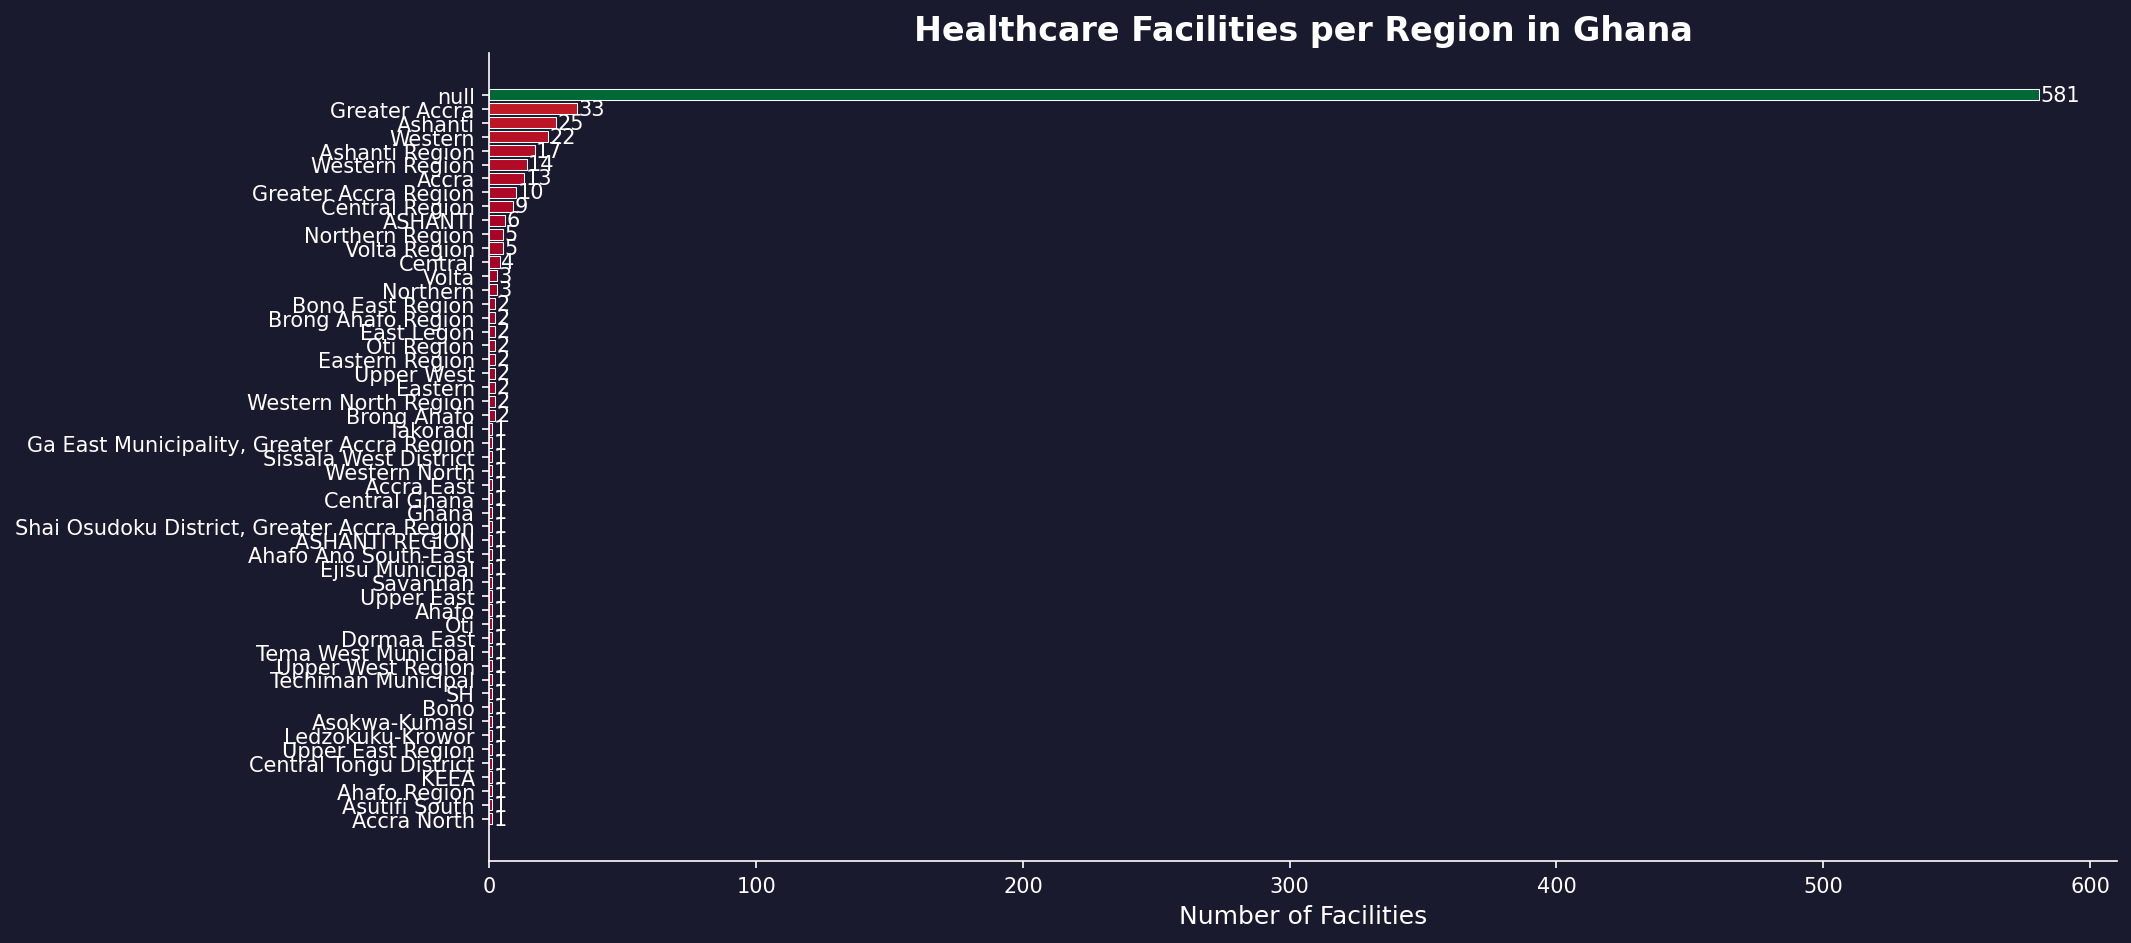
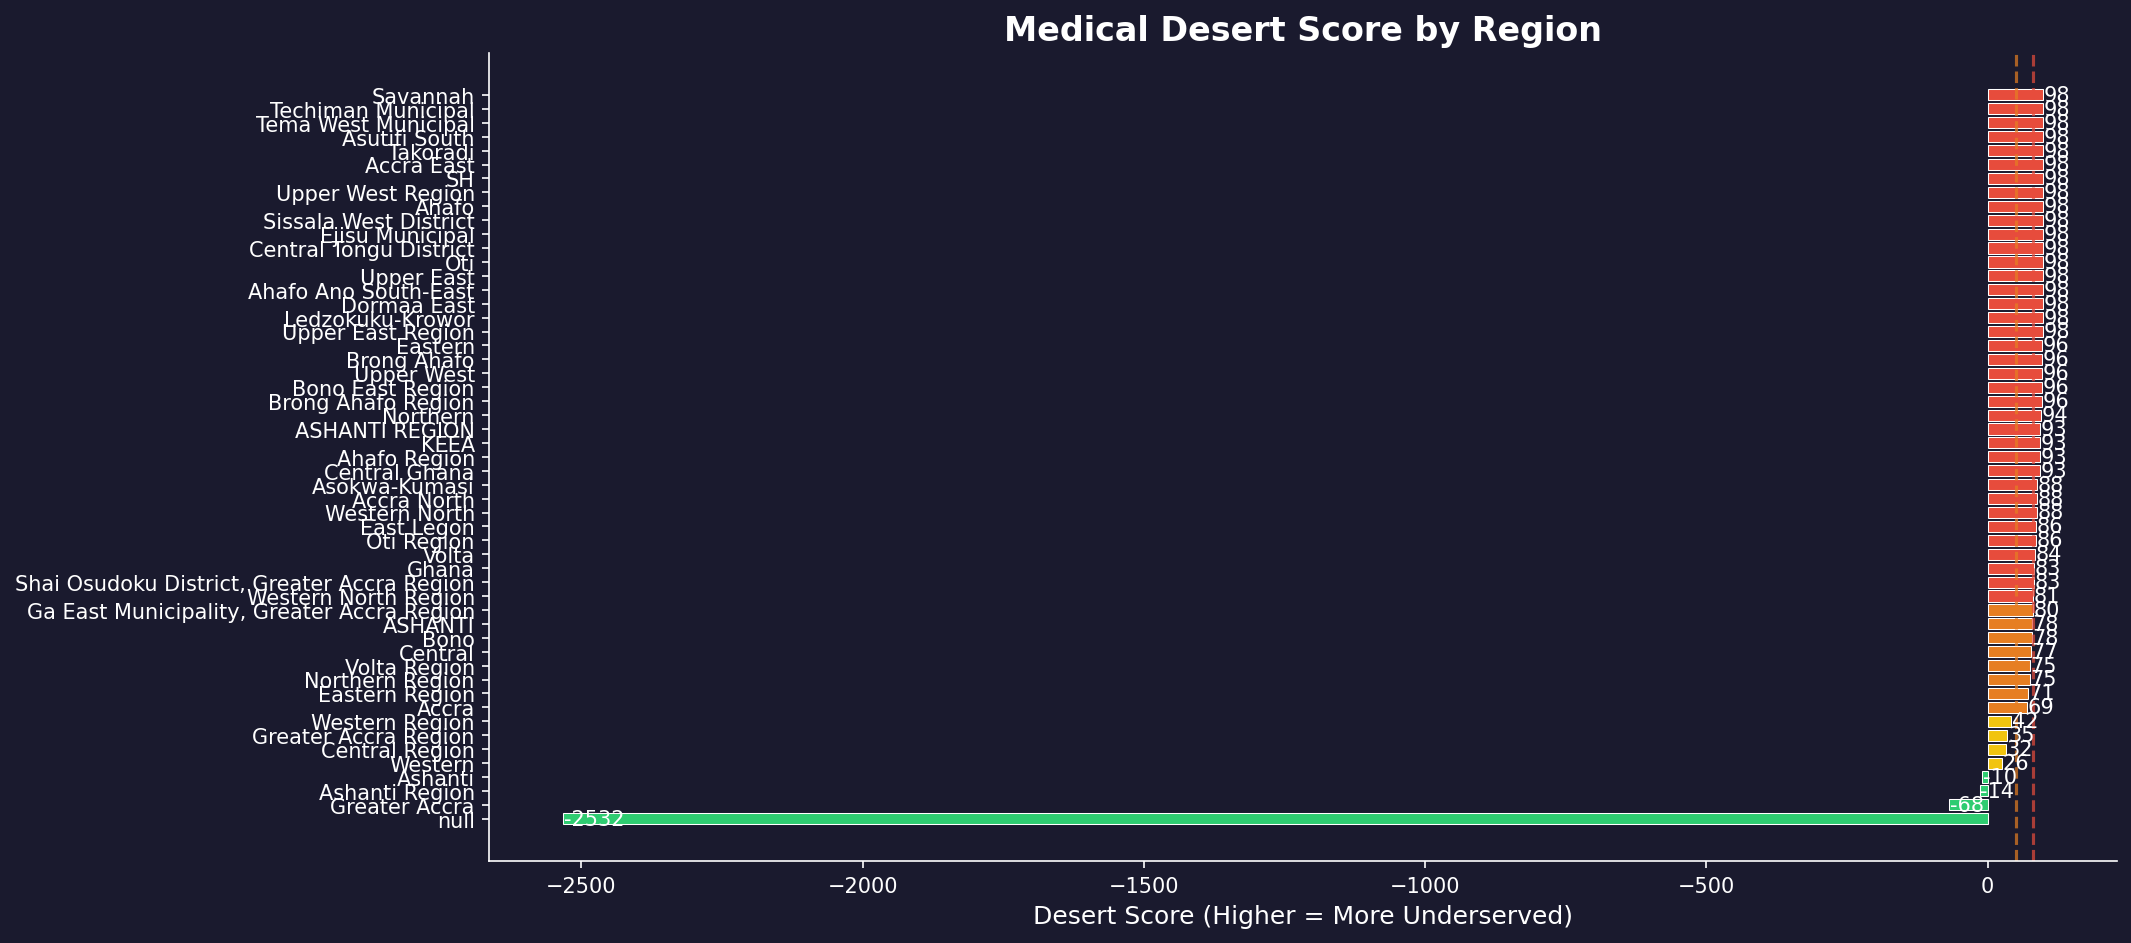
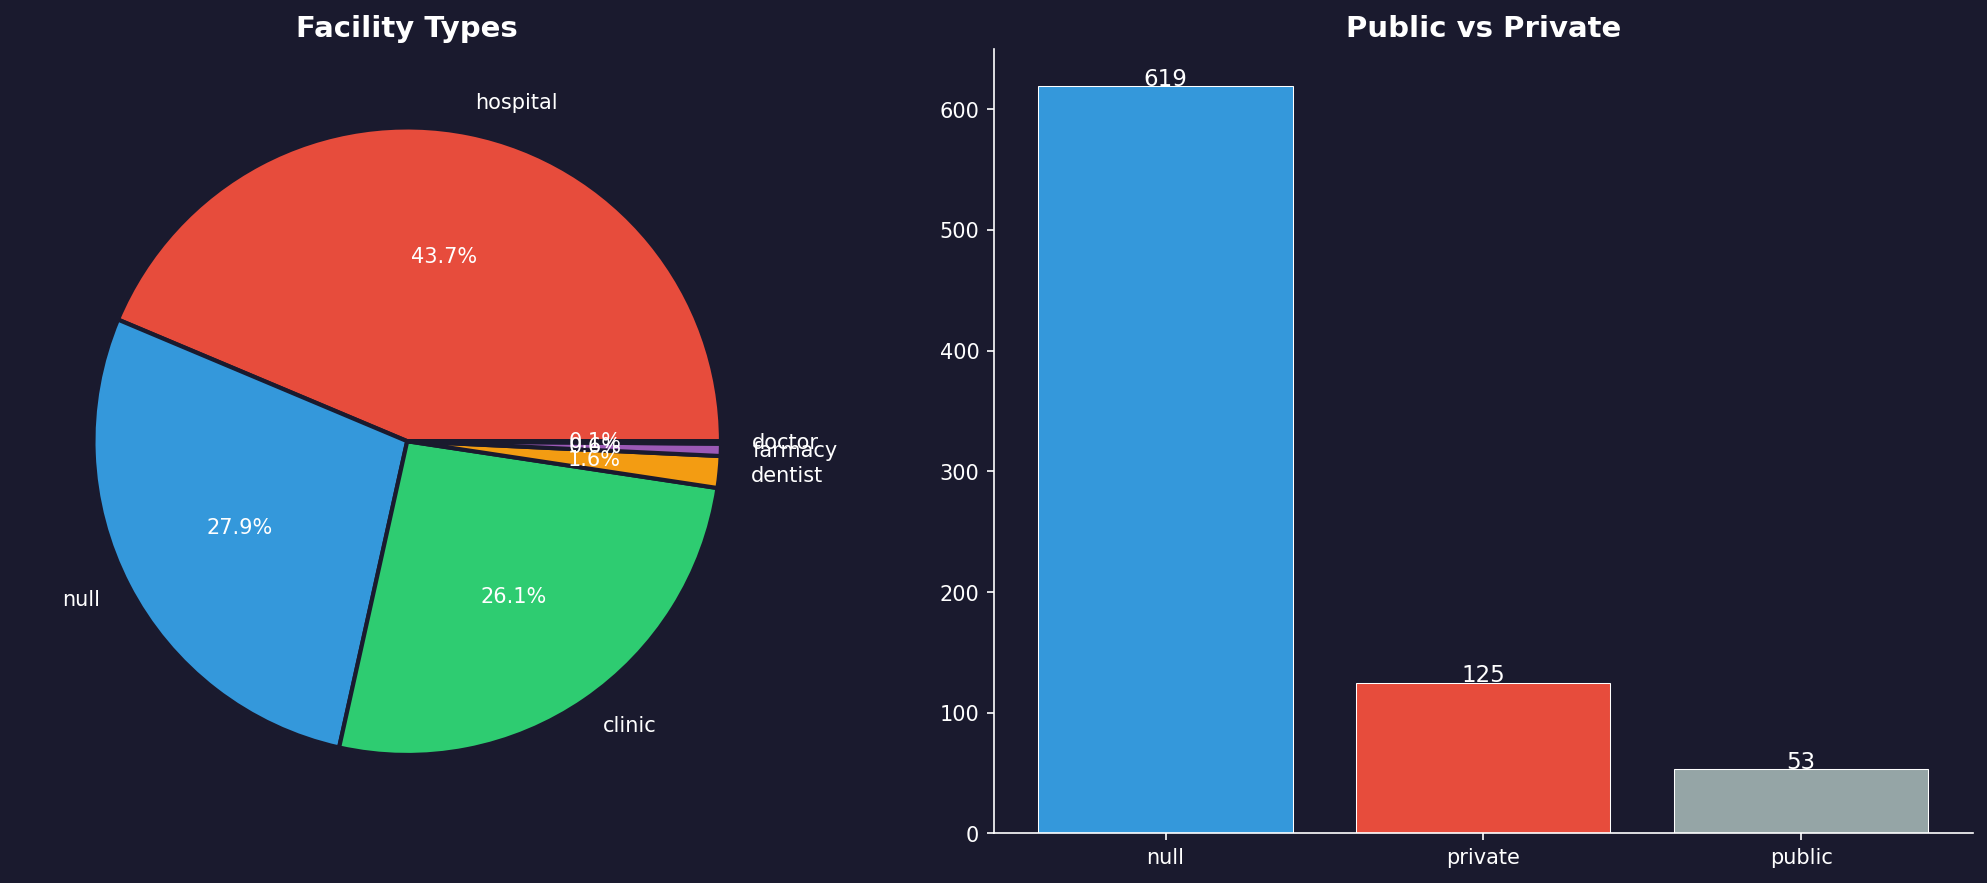
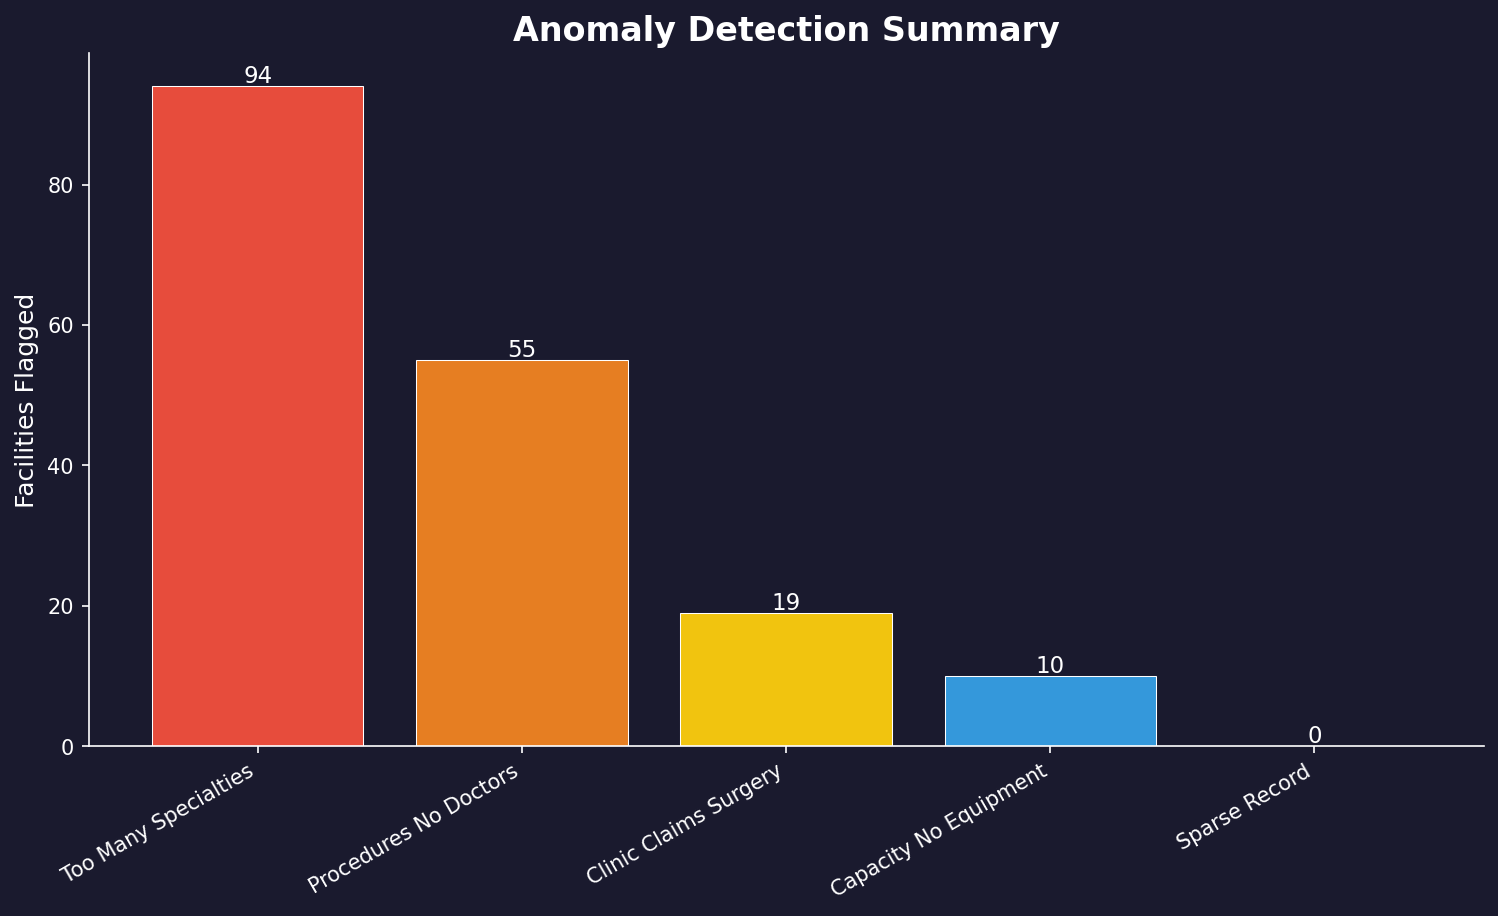

In [0]:
# Build combined dashboard HTML
dashboard_html = f"""
<html>
<head>
    <style>
        body {{ background-color: #1a1a2e; color: white; font-family: 'Segoe UI', Arial, sans-serif; margin: 0; padding: 20px; }}
        .dashboard-title {{ text-align: center; font-size: 28px; font-weight: bold; color: #ecf0f1;
                           margin-bottom: 10px; text-shadow: 0 0 10px rgba(52,152,219,0.5); }}
        .dashboard-subtitle {{ text-align: center; font-size: 16px; color: #bdc3c7; margin-bottom: 30px; }}
        .stats-grid {{ display: grid; grid-template-columns: repeat(5, 1fr); gap: 15px; margin-bottom: 30px; }}
        .stat-card {{ background: linear-gradient(135deg, #2c3e50, #34495e); border-radius: 12px;
                     padding: 20px; text-align: center; box-shadow: 0 4px 15px rgba(0,0,0,0.3); }}
        .stat-value {{ font-size: 36px; font-weight: bold; margin: 5px 0; }}
        .stat-label {{ font-size: 13px; color: #95a5a6; text-transform: uppercase; letter-spacing: 1px; }}
        .chart-row {{ display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 20px; }}
        .chart-card {{ background: #16213e; border-radius: 12px; padding: 15px; }}
        .chart-title {{ font-size: 16px; font-weight: bold; color: #ecf0f1; margin-bottom: 10px; }}
    </style>
</head>
<body>
    <div class="dashboard-title">🏥 Healthcare Intelligence Dashboard</div>
    <div class="dashboard-subtitle">Virtue Foundation — Ghana Healthcare Facility Analysis</div>

    <div class="stats-grid">
        <div class="stat-card">
            <div class="stat-label">Total Facilities</div>
            <div class="stat-value" style="color: #3498db;">{len(facilities_pdf)}</div>
        </div>
        <div class="stat-card">
            <div class="stat-label">Hospitals</div>
            <div class="stat-value" style="color: #e74c3c;">{len(facilities_pdf[facilities_pdf['facilityTypeId'] == 'hospital'])}</div>
        </div>
        <div class="stat-card">
            <div class="stat-label">Regions</div>
            <div class="stat-value" style="color: #2ecc71;">{facilities_pdf['address_stateOrRegion'].nunique()}</div>
        </div>
        <div class="stat-card">
            <div class="stat-label">Total Doctors</div>
            <div class="stat-value" style="color: #f39c12;">{int(facilities_pdf['numberDoctors'].fillna(0).astype(float).sum())}</div>
        </div>
        <div class="stat-card">
            <div class="stat-label">Anomalies Flagged</div>
            <div class="stat-value" style="color: #e74c3c;">{int(facilities_pdf[[c for c in facilities_pdf.columns if c.startswith('flag_')]].any(axis=1).sum())}</div>
        </div>
    </div>

    <div class="chart-row">
        <div class="chart-card">
            <div class="chart-title">📊 Facilities by Region</div>
            {chart1_html}
        </div>
        <div class="chart-card">
            <div class="chart-title">📊 Desert Scores</div>
            {chart4_html}
        </div>
    </div>
    <div class="chart-row">
        <div class="chart-card">
            <div class="chart-title">📊 Facility Types & Operators</div>
            {chart2_html}
        </div>
        <div class="chart-card">
            <div class="chart-title">⚠️ Anomaly Flags</div>
            {chart3_html}
        </div>
    </div>
</body>
</html>
"""

displayHTML(dashboard_html)

## 8H. Anomaly Table

In [0]:
print("=== FLAGGED FACILITIES ===\n")
flag_cols = [c for c in facilities_pdf.columns if c.startswith("flag_")]
flagged = facilities_pdf[facilities_pdf[flag_cols].any(axis=1)]

display_cols = ["name", "address_stateOrRegion", "facilityTypeId", "numberDoctors",
                "capacity", "num_procedures", "num_equipment", "num_specialties"] + flag_cols

# Convert all to string first so fillna("N/A") doesn't cause PyArrow type errors
flagged_spark = spark.createDataFrame(flagged[display_cols].astype(str).replace("nan", "N/A").replace("None", "N/A"))
display(flagged_spark)

=== FLAGGED FACILITIES ===



name,address_stateOrRegion,facilityTypeId,numberDoctors,capacity,num_procedures,num_equipment,num_specialties,flag_procedures_no_doctors,flag_capacity_no_equipment,flag_clinic_claims_surgery,flag_too_many_specialties,flag_sparse_record
"Behind the Chief's Palace Abesim, Ghana",null,null,N/A,N/A,6,0,6,True,False,False,True,False
A & A Medlove Medical Centre,null,null,N/A,N/A,10,0,6,True,False,False,True,False
Accra Newtown Islamic Hospital,null,hospital,N/A,N/A,4,2,7,False,False,False,True,False
Accra Psychiatric Hospital,null,hospital,N/A,N/A,0,0,7,False,False,False,True,False
Accra Specialist Eye Hospital,null,hospital,N/A,N/A,26,7,9,True,False,False,True,False
Acrecity Medics,null,clinic,N/A,N/A,2,0,11,False,False,True,True,False
Adiebeba Specialist Hospital,null,hospital,N/A,N/A,11,2,12,True,False,False,True,False
"Ahmadiyya Muslim Hospital, Techiman",Bono East Region,hospital,N/A,100.0,6,0,1,True,True,False,False,False
Aisha Hospital,null,hospital,N/A,N/A,3,1,11,False,False,False,True,False
Akatsi South Municipal Hospital,null,hospital,N/A,N/A,9,0,14,True,False,False,True,False


## 8I. Regional Summary Table

In [0]:
display(df_desert.orderBy("desert_score", ascending=False))

address_stateOrRegion,facility_count,total_doctors,total_beds,hospital_count,has_surgery,has_emergency,has_obstetrics,has_pediatrics,sparse_records,desert_score
Central Tongu District,1,0,0,1,0,0,0,0,0,98
Accra East,1,0,0,0,0,0,0,1,0,98
Ledzokuku-Krowor,1,0,0,0,0,0,0,0,0,98
Ahafo Ano South-East,1,0,0,1,0,0,0,0,0,98
Ejisu Municipal,1,0,0,1,0,0,0,0,0,98
Upper West Region,1,0,0,0,0,0,0,0,0,98
Upper East,1,0,0,1,0,0,0,0,0,98
Ahafo,1,0,0,1,0,0,0,0,0,98
Upper East Region,1,0,0,1,0,0,0,1,0,98
Takoradi,1,0,0,0,0,0,0,0,0,98


In [0]:
print("=" * 60)
print("STEP 8 COMPLETE: Visualization & Dashboard")
print("=" * 60)
print(f"""
What we built:
  - Interactive Folium map with all facilities (color-coded by type)
  - Medical desert heatmap with desert scores
  - Bar charts: facilities per region, desert scores
  - Pie chart: facility type distribution
  - Anomaly flag summary chart
  - Combined HTML dashboard with KPI cards
  - Flagged facilities table
  - Regional summary table

All visualizations are rendered inline in the Databricks notebook.
Charts use a premium dark theme with color-coded data.

Next: Run notebook 09_mlflow_tracing
""")

STEP 8 COMPLETE: Visualization & Dashboard

What we built:
  - Interactive Folium map with all facilities (color-coded by type)
  - Medical desert heatmap with desert scores
  - Bar charts: facilities per region, desert scores
  - Pie chart: facility type distribution
  - Anomaly flag summary chart
  - Combined HTML dashboard with KPI cards
  - Flagged facilities table
  - Regional summary table

All visualizations are rendered inline in the Databricks notebook.
Charts use a premium dark theme with color-coded data.

Next: Run notebook 09_mlflow_tracing

